# Binary images and connected components

Juan Diego Perez Navarro  
T00067699

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# Constantes
CONN = 4  # 8-way || 4-way
AREA_MIN: int = 500
AREA_MAX: int = 100_000

TODO:

>Process the image blobs.jpg and count the number of white blobs using connected components (it's already a binary image)

In [3]:
def plot_grayscale(image: np.ndarray, ax: plt.Axes = None, **kwargs) -> None:
    """
    Display a grayscale image using matplotlib.
    
    Parameters:
        image (numpy.ndarray): The grayscale image to display.
        ax (matplotlib.axes.Axes, optional): The axes to plot on. If None, a new figure is created.

    """
    if ax is None:
        _, ax = plt.subplots()
    ax.imshow(image, cmap='gray')
    ax.set(**kwargs)
    ax.axis('off')

In [4]:
def filter_stats(stats: np.ndarray) -> bool:
    """"
    Filter based on stats if its a blob or not.

    Parameters:
        stats (numpy.ndarray): A 1-D array representing the stats of the blob.

    Returns:
        bool: True if the blob is valid, False otherwise.
    """
    area = stats[cv2.CC_STAT_AREA]

    # Filter by area
    is_valid_area = AREA_MIN < area < AREA_MAX
    # If there are new ways to filter the stats
    # just add theme here and to the return statement

    return is_valid_area

It's a binary image:
[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]]
(512, 512)


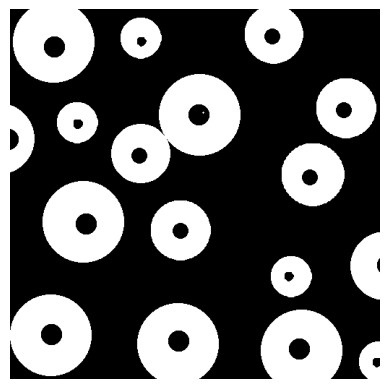

In [5]:
IMAGE_URL = 'https://github.com/agmarrugo/computer-vision-utb/blob/main/data/blobs.jpg?raw=true'

image = io.imread(IMAGE_URL)
plot_grayscale(image)
print(f"It's a binary image:\n{image}\n{image.shape}")

## Sin separar los blobs de la mitad

Número de blobs esperados: 16 si se considera dos blobs que están parcialmente unidos (en la parte central de la imagen) como uno solo 😸.

In [26]:
output = cv2.connectedComponentsWithStats(image,
                                          connectivity=CONN,
                                          ltype=cv2.CV_32S)
(num_labels, labels, stats, centroids) = output
print("Number of labels:", num_labels)
print("Labels:", labels.shape)
print("Stats:", stats.shape)
print("Centroids:", centroids.shape)

Number of labels: 582
Labels: (512, 512)
Stats: (582, 5)
Centroids: (582, 2)


In [27]:
stats_filtered = np.array(list(
    filter(lambda s: filter_stats(s), stats)
))

print(f"Filtered Stats: {stats_filtered.shape}")

Filtered Stats: (16, 5)


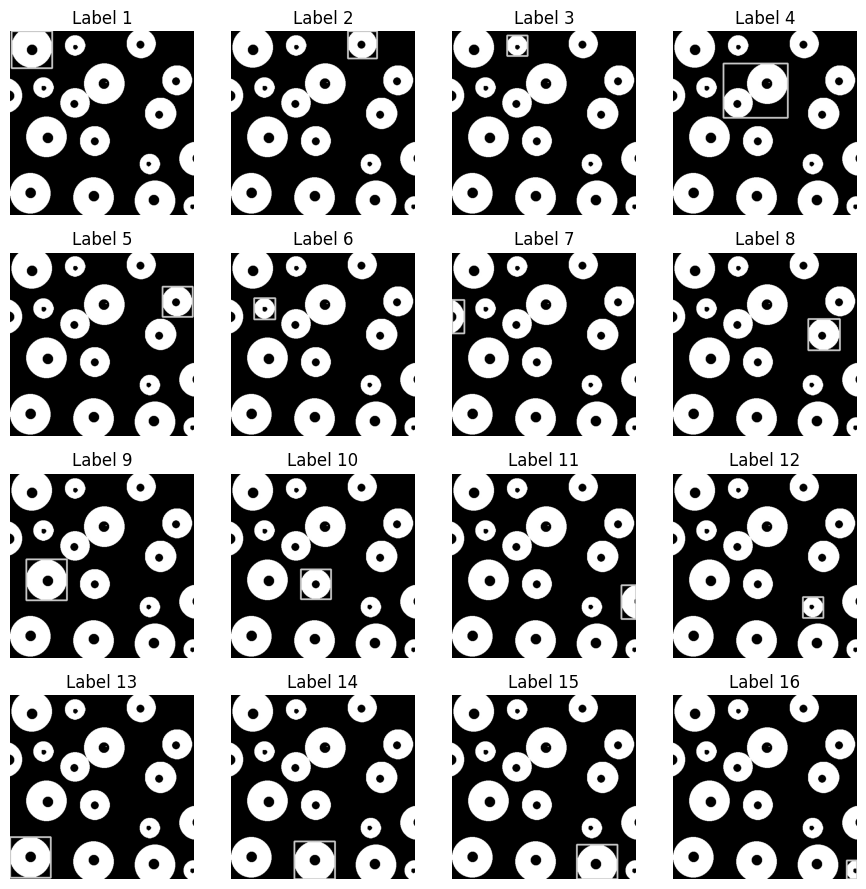

In [28]:
fig, axes = plt.subplots(4, 4, figsize=(9, 9))
num_labels = stats_filtered.shape[0]

for i, ax in zip(range(num_labels), axes.flatten()):
    x = stats_filtered[i, cv2.CC_STAT_LEFT]
    y = stats_filtered[i, cv2.CC_STAT_TOP]
    w = stats_filtered[i, cv2.CC_STAT_WIDTH]
    h = stats_filtered[i, cv2.CC_STAT_HEIGHT]
    area = stats_filtered[i, cv2.CC_STAT_AREA]
    output = image.copy()
    cv2.rectangle(output, (x, y), (x + w, y + h), 200, 3)
    plot_grayscale(output, ax=ax, title=f"Label {i+1}")

fig.tight_layout()
plt.show()

## Separando los blobs de la mitad

Número esperado de blobs: 17, tomando por separado los blobs que están parcialmente unidos en el centro de la imagen. 😿

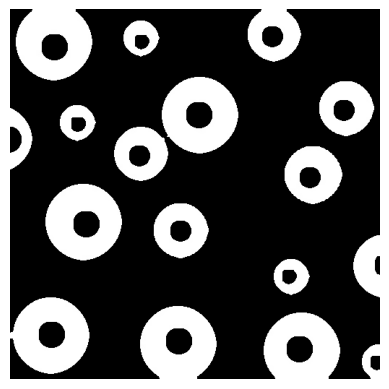

In [37]:
# Validos: MORPH_RECT, MORPH_CROSS, MORPH_ELLIPSE
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (8, 8))
eroded_image = cv2.erode(image, kernel, iterations=1)
plot_grayscale(eroded_image)

In [38]:
output = cv2.connectedComponentsWithStats(eroded_image,
                                          connectivity=CONN,
                                          ltype=cv2.CV_32S)
(num_labels, labels, stats, centroids) = output

Filtered Stats: 17
Filtered Stats: (17, 5)


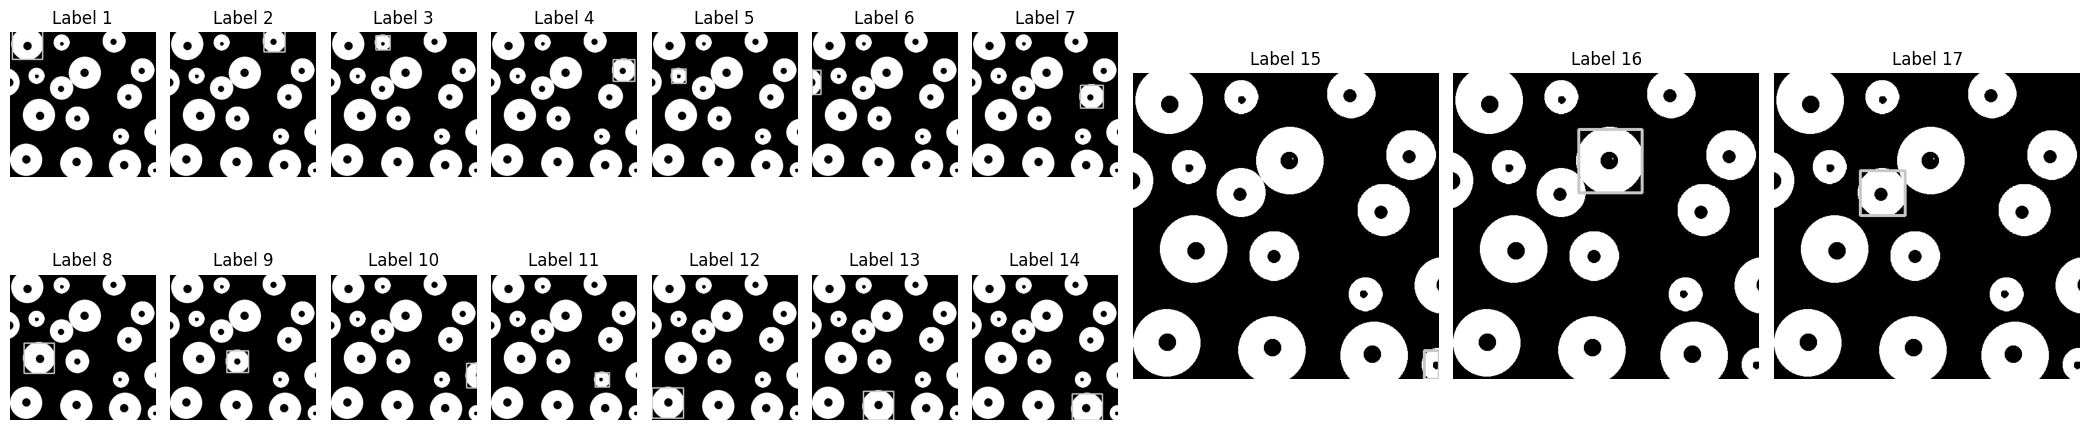

In [ ]:
stats_filtered = list(
    filter(lambda s: filter_stats(s), stats)
)

print(f"Filtered Stats: {len(stats_filtered)}")

# La cuadricula más sencilla es 17x1, pero no me gusta que sean tan extensas en una dirección
# así que haré una 2x13, que sigue siendo largo en Y, pero no tanto como 17
# Que ardan en lo más profundo del infierno los números primos para graficar
fig, axes = plt.subplots(2, 13, figsize=(21, 5))
num_labels = len(stats_filtered)

# Las etiquetas 4 y 8 es donde está la diferencia respecto a antes, así que las pondré al final para luego graficar
# algo así como darle más importancia

# 1er paso. Moverlas para que estén al final (lo sé porque grafiqué antes de escribir esto)
stats_filtered.append(stats_filtered[3])
stats_filtered.append(stats_filtered[7])
del stats_filtered[7]
del stats_filtered[3]

# 2do paso. Tomar los últimos 4 axes para mostrar cada etiqueta relevante

# Función para decidir si el eje se puede usar normal o no
def keep_ax(ax: plt.Axes) -> bool:
    try:
        ax.set_title("")
    except AttributeError:
        return False
    return True


gs = axes[0, 0].get_gridspec()
for ax in axes[:, 7:].flatten():
    ax.remove()

axes = list(filter(keep_ax, axes.flatten()))

axbig1 = fig.add_subplot(gs[:, 7:9])  # No es tan relevante para un eje grande, pero sino se coloca así, queda feo (a mi parecer)
axbig2 = fig.add_subplot(gs[: ,9:11])
axbig3 = fig.add_subplot(gs[: ,11:13])

# 3er paso. Crear un arreglo de NumPy por convenencia
stats_filtered = np.array(stats_filtered)
print(f"Filtered Stats: {stats_filtered.shape}")

# Hacer las gráficas correspondiente
for i, ax in zip(range(num_labels), [*axes, axbig1, axbig2, axbig3]):
    x = stats_filtered[i, cv2.CC_STAT_LEFT]
    y = stats_filtered[i, cv2.CC_STAT_TOP]
    w = stats_filtered[i, cv2.CC_STAT_WIDTH]
    h = stats_filtered[i, cv2.CC_STAT_HEIGHT]
    area = stats_filtered[i, cv2.CC_STAT_AREA]
    output = image.copy()
    cv2.rectangle(output, (x, y), (x + w, y + h), 200, 3)

    plot_grayscale(output, ax=ax, title=f"Label {i+1}")

fig.tight_layout()
plt.show()